# Explainer Notebook: Trust, Communities, and Language in Wikipedia RfA

This notebook consolidates our Project 1 dataset exploration and the later experimental analysis into one reproducible explainer for Project Assignment B.

We study the **Wikipedia Requests for Adminship (RfA)** dataset. Each row is a public vote from one Wikipedia editor (`SRC`) about whether another editor (`TGT`) should become an administrator. The data is useful because it combines three things in one place: a social interaction network, an explicit decision (`support`, `oppose`, or `neutral`), and the text people wrote to justify that decision.

The notebook is structured according to the assignment requirements:

1. **Motivation**: what the dataset is, why it matters, and what experience we want the website reader to have.
2. **Basic stats**: cleaning choices and descriptive statistics.
3. **Tools, theory and analysis**: network analysis, community detection, brokers, sentiment, and text analysis.
4. **Discussion**: what worked, what is still missing, and how the project could be improved.


## 1. Motivation

### What is the dataset?

The dataset is the Stanford SNAP **Wikipedia Requests for Adminship (RfA)** voting network. In Wikipedia, becoming an administrator requires public community approval. Editors vote on candidates and often leave a short explanation. The fields we use are:

- `SRC`: the editor casting a vote.
- `TGT`: the candidate being voted on.
- `VOT`: vote direction (`1` = support, `-1` = oppose, `0` = neutral/abstain).
- `RES`: final outcome of the request (`1` = successful, `-1` = unsuccessful).
- `YEA` and `DAT`: year and timestamp information.
- `TXT`: the voter's written rationale.

### Why this dataset?

We chose this dataset because it is a compact example of online governance. It is not just a list of posts: every text comment is tied to a social action, a decision, and a relationship between two users. That lets us ask questions that combine network science and text analysis:

- Are Wikipedia adminship decisions driven by isolated individual votes, or by visible communities of editors?
- Do communities mostly vote inside their own group, or across group boundaries?
- Are highly connected editors simply active voters, or do some act as brokers between communities?
- Does the language of support, opposition, and neutrality differ in meaningful ways?

### Goal for the end-user experience

The website should tell a non-technical story about trust and decision-making in an online community. The reader should be able to understand that each vote is a link, that clusters of editors form communities, and that written explanations reveal the social meaning behind the votes. The goal is not to present every formula, but to let the reader explore how network structure and language combine in a real governance process.


## 2. Basic Stats: Understanding the Dataset

Before doing network or text analysis, we parse the raw text file, standardize the important fields, and check the core properties of the data. The raw file is record-based rather than a normal CSV: each vote is stored as several key-value lines separated by blank lines. The parser below converts that format into a `pandas` DataFrame.


In [1]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from networkx.algorithms import community as nx_comm
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = "wiki-RfA.txt"


def parse_rfa(filepath):
    """Parse SNAP's record-based wiki-RfA text file into a DataFrame."""
    records = []
    current = {}
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line.strip():
                if current:
                    records.append(current)
                    current = {}
                continue
            if ":" in line:
                key, value = line.split(":", 1)
                current[key.strip()] = value.strip()
    if current:
        records.append(current)
    return pd.DataFrame(records)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Expected {DATA_PATH} in the repository root.")

raw_df = parse_rfa(DATA_PATH)
df = raw_df.copy()

# Standardize types used in the analysis.
for col in ["SRC", "TGT", "TXT", "DAT"]:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["VOT"] = pd.to_numeric(df["VOT"], errors="coerce")
df["RES"] = pd.to_numeric(df["RES"], errors="coerce")
df["YEA"] = pd.to_numeric(df["YEA"], errors="coerce")
df["TXT"] = df["TXT"].fillna("")

# Drop rows that cannot form a valid vote edge or vote label.
df = df[(df["SRC"] != "") & (df["TGT"] != "") & df["VOT"].isin([-1, 0, 1])].copy()

print(f"Rows after cleaning: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()


Rows after cleaning: 196,614
Columns: ['SRC', 'TGT', 'VOT', 'RES', 'YEA', 'DAT', 'TXT']


,SRC,TGT,VOT,RES,YEA,DAT,TXT
0,Steel1943,BDD,1,1,2013,"23:13, 19 April 2013",'''Support''' as co-nom.
1,Cuchullain,BDD,1,1,2013,"01:04, 20 April 2013",'''Support''' as nominator.--
2,INeverCry,BDD,1,1,2013,"23:43, 19 April 2013",'''Support''' per noms.
3,Cncmaster,BDD,1,1,2013,"00:11, 20 April 2013",'''Support''' per noms. BDD is a strong contri...
4,Miniapolis,BDD,1,1,2013,"00:56, 20 April 2013","'''Support''', with great pleasure. I work wit..."


In [2]:
file_size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
unique_voters = df["SRC"].nunique()
unique_candidates = df["TGT"].nunique()
unique_users = pd.Index(df["SRC"].tolist() + df["TGT"].tolist()).nunique()
text_nonempty = (df["TXT"].str.len() > 0).mean()

summary = pd.DataFrame({
    "metric": [
        "raw file size (MB)",
        "votes / rows",
        "unique voters (SRC)",
        "unique candidates (TGT)",
        "unique users (SRC + TGT)",
        "years covered",
        "rows with non-empty text",
    ],
    "value": [
        f"{file_size_mb:.2f}",
        f"{len(df):,}",
        f"{unique_voters:,}",
        f"{unique_candidates:,}",
        f"{unique_users:,}",
        f"{int(df['YEA'].min())}-{int(df['YEA'].max())}",
        f"{text_nonempty:.1%}",
    ],
})
summary


,metric,value
0,raw file size (MB),47.79
1,votes / rows,"196,614"
2,unique voters (SRC),"10,416"
3,unique candidates (TGT),"3,491"
4,unique users (SRC + TGT),"11,377"
5,years covered,2003-2013
6,rows with non-empty text,97.2%


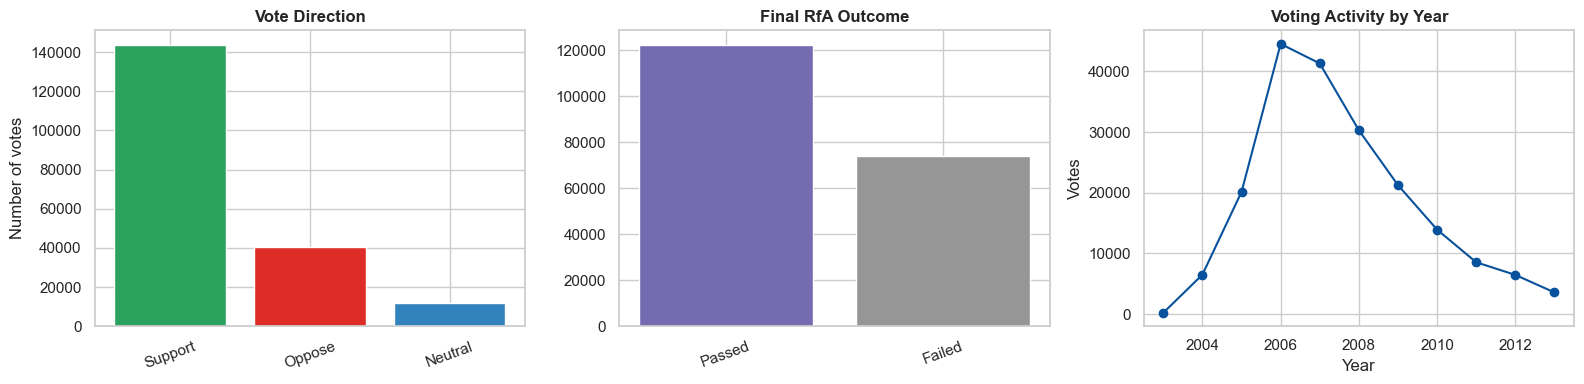

Vote counts:
VOT
Support    143879
Oppose      40667
Neutral     12068

Outcome counts:
RES
Passed    122524
Failed     74090


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vote_labels = {-1: "Oppose", 0: "Neutral", 1: "Support"}
result_labels = {-1: "Failed", 1: "Passed"}

vote_counts = df["VOT"].map(vote_labels).value_counts().reindex(["Support", "Oppose", "Neutral"])
result_counts = df["RES"].map(result_labels).value_counts().reindex(["Passed", "Failed"])
year_counts = df.groupby("YEA").size()

axes[0].bar(vote_counts.index, vote_counts.values, color=["#2ca25f", "#de2d26", "#3182bd"])
axes[0].set_title("Vote Direction")
axes[0].set_ylabel("Number of votes")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(result_counts.index, result_counts.values, color=["#756bb1", "#969696"])
axes[1].set_title("Final RfA Outcome")
axes[1].tick_params(axis="x", rotation=20)

axes[2].plot(year_counts.index, year_counts.values, marker="o", color="#08519c")
axes[2].set_title("Voting Activity by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Votes")

plt.tight_layout()
plt.show()

print("Vote counts:")
print(vote_counts.to_string())
print("\nOutcome counts:")
print(result_counts.to_string())


### Basic stats interpretation

The dataset is large enough for network analysis: it contains almost 200,000 vote records and more than 11,000 unique users. Support votes are much more common than opposition votes, and neutral votes are relatively rare. This matters for interpretation because a naive model could conclude that the community is mostly positive simply because most RfA votes are support votes. For the rest of the notebook we therefore compare support and opposition both **within communities** and **across communities**, instead of only looking at global averages.

Cleaning choices were deliberately conservative. We kept the original vote labels, preserved the raw text, and only removed rows that lacked a valid source, target, or vote direction. For text analysis, additional cleaning is performed later so that the raw dataset remains available for other analyses.


## 3. Tools, Theory and Analysis

### Network representation

We model the data as a **directed graph**. A directed edge from `SRC` to `TGT` means that the source editor voted on the target editor's adminship request. Direction matters because casting a vote and being evaluated are different roles. If the same pair appears multiple times, we store a weight and counts of support, opposition, and neutral votes.

The graph helps us move from individual vote records to social structure. Degree tells us who is highly active or highly evaluated. Community detection tells us whether users form clusters. Betweenness centrality helps us identify brokers: users positioned on paths between otherwise separated parts of the network.


In [4]:
G = nx.DiGraph()

for row in df.itertuples(index=False):
    src, tgt, vote = row.SRC, row.TGT, int(row.VOT)
    if G.has_edge(src, tgt):
        G[src][tgt]["weight"] += 1
    else:
        G.add_edge(src, tgt, weight=1, support=0, oppose=0, neutral=0)
    if vote == 1:
        G[src][tgt]["support"] += 1
    elif vote == -1:
        G[src][tgt]["oppose"] += 1
    else:
        G[src][tgt]["neutral"] += 1

G_und = G.to_undirected()

network_stats = pd.DataFrame({
    "metric": [
        "nodes",
        "unique directed edges",
        "raw vote records",
        "density",
        "weakly connected components",
        "largest weak component size",
        "degree assortativity",
    ],
    "value": [
        f"{G.number_of_nodes():,}",
        f"{G.number_of_edges():,}",
        f"{len(df):,}",
        f"{nx.density(G):.5f}",
        nx.number_weakly_connected_components(G),
        f"{len(max(nx.weakly_connected_components(G), key=len)):,}",
        f"{nx.degree_assortativity_coefficient(G):.4f}",
    ],
})
network_stats


,metric,value
0,nodes,"11,377"
1,unique directed edges,"188,077"
2,raw vote records,"196,614"
3,density,0.00145
4,weakly connected components,1
5,largest weak component size,"11,377"
6,degree assortativity,-0.0869


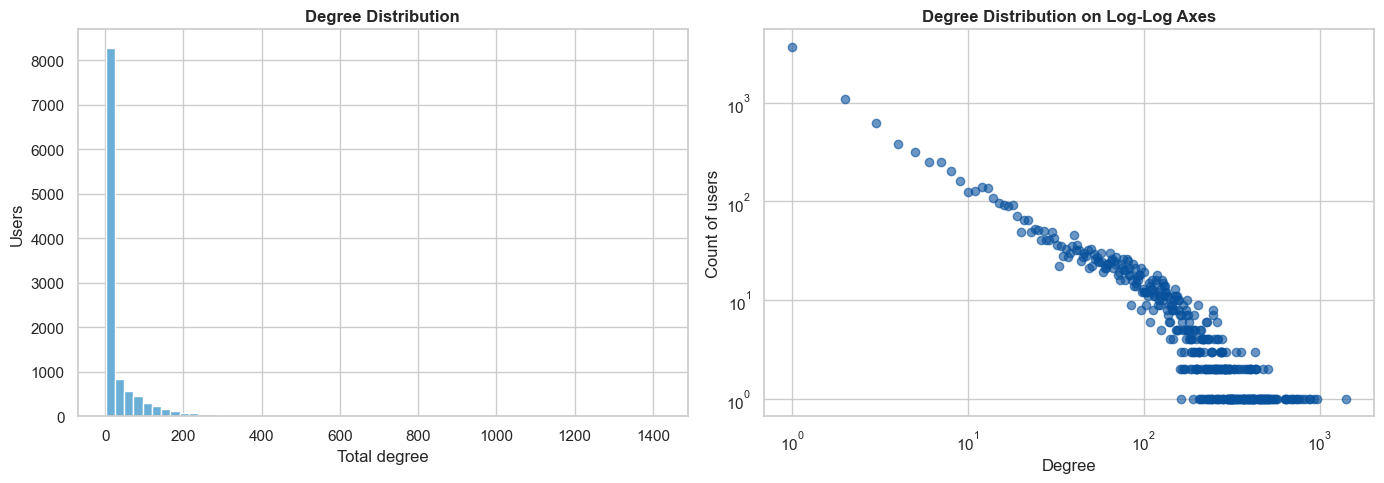

,node,in_degree,out_degree,degree
2204,Siva1979,317,1101,1418
909,Mailer diablo,30,936,966
821,Everyking,725,206,931
3268,Merovingian,18,860,878
97,MONGO,350,522,872
349,Acalamari,163,660,823
43,Wizardman,67,730,797
2468,Majorly,355,404,759
85,Pedro,146,596,742
4190,Xoloz,149,590,739


In [5]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
total_degree = dict(G.degree())

degree_df = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_degree[n] for n in G.nodes()],
    "out_degree": [out_degree[n] for n in G.nodes()],
    "degree": [total_degree[n] for n in G.nodes()],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(degree_df["degree"], bins=60, color="#6baed6", edgecolor="white")
axes[0].set_title("Degree Distribution")
axes[0].set_xlabel("Total degree")
axes[0].set_ylabel("Users")

counts = degree_df["degree"].value_counts().sort_index()
axes[1].scatter(counts.index, counts.values, alpha=0.6, color="#08519c")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Degree Distribution on Log-Log Axes")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Count of users")

plt.tight_layout()
plt.show()

degree_df.sort_values("degree", ascending=False).head(10)


### Degree distribution interpretation

The degree plots show a highly uneven network. Most users have few connections, while a small number of users are connected to hundreds or more than a thousand voting relationships. This is typical of online participation systems: many people participate occasionally, but a smaller core of highly active editors contributes heavily to governance. The log-log view makes the long tail visible and motivates centrality analysis, because averages alone hide the importance of these central users.


In [6]:
communities = list(nx_comm.greedy_modularity_communities(G_und))
partition = {node: i for i, comm in enumerate(communities) for node in comm}
nx.set_node_attributes(G, partition, "community")
modularity = nx_comm.modularity(G_und, communities)

community_sizes = pd.Series([len(c) for c in communities], name="size").sort_values(ascending=False)
print(f"Detected communities: {len(communities)}")
print(f"Modularity: {modularity:.4f}")
community_sizes.head(15).to_frame()


Detected communities: 13
Modularity: 0.4096


,size
0,5247
1,5029
2,996
3,79
4,7
5,3
6,3
7,3
8,2
9,2


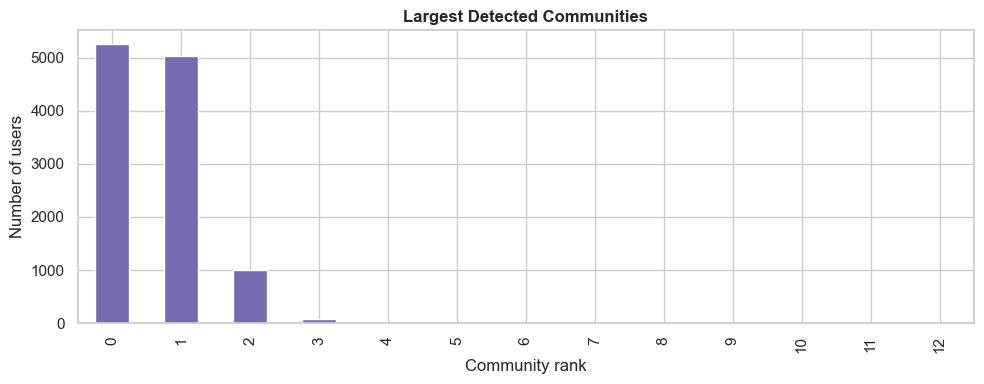

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
community_sizes.head(15).plot(kind="bar", ax=ax, color="#756bb1")
ax.set_title("Largest Detected Communities")
ax.set_xlabel("Community rank")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.show()


### Community detection interpretation

We use greedy modularity community detection on the undirected projection of the graph. The undirected projection is used only for clustering because modularity asks whether users are more densely connected to each other than expected by chance; for that structural question, the existence of a relationship is more important than its direction.

The modularity score is moderate, which means the RfA network has recognizable communities rather than being one uniform mass. The important next question is whether those communities behave differently, or whether they are mostly structural clusters of active editors who vote in similar ways.


In [8]:
# Approximate betweenness keeps the notebook practical on a graph with more than 11k nodes.
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G, k=150, normalized=True, seed=42)

cross_edges = {n: 0 for n in G.nodes()}
for u, v in G.edges():
    if partition.get(u) != partition.get(v):
        cross_edges[u] += 1
        cross_edges[v] += 1

nodes_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "in_degree": [in_degree[n] for n in G.nodes()],
    "out_degree": [out_degree[n] for n in G.nodes()],
    "community": [partition[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "cross_edges": [cross_edges[n] for n in G.nodes()],
})

nodes_df["broker_score"] = (
    0.6 * nodes_df["betweenness"] / nodes_df["betweenness"].max()
    + 0.4 * nodes_df["cross_edges"] / nodes_df["cross_edges"].max()
)

top_brokers = nodes_df.sort_values("broker_score", ascending=False).head(15)
top_brokers[["node", "community", "degree", "betweenness", "cross_edges", "broker_score"]]


,node,community,degree,betweenness,cross_edges,broker_score
821,Everyking,3,931,0.029380,883,1.000000
2204,Siva1979,1,1418,0.011170,634,0.515323
97,MONGO,1,872,0.016954,343,0.501628
2468,Majorly,0,759,0.010346,328,0.359876
1815,Richardcavell,0,406,0.008739,218,0.277221
31,Newyorkbrad,0,698,0.002802,406,0.241138
43,Wizardman,0,797,0.004597,301,0.230231
4244,Elonka,2,512,0.002668,374,0.223914
349,Acalamari,0,823,0.003043,328,0.210738
909,Mailer diablo,1,966,0.002174,349,0.202497


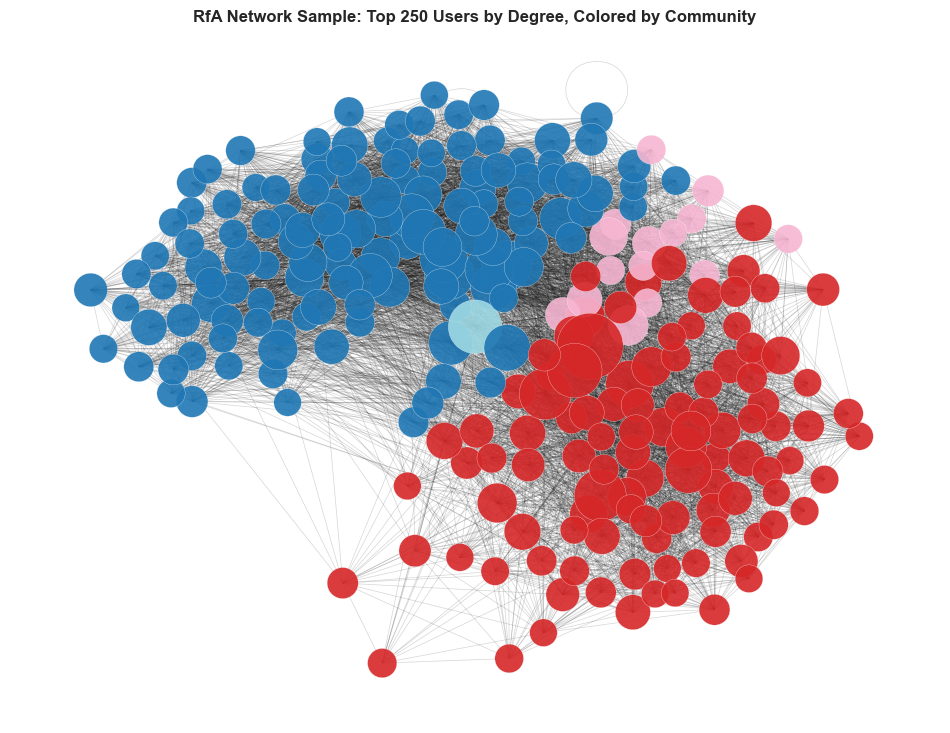

In [9]:
top_n = 250
top_nodes = nodes_df.sort_values("degree", ascending=False).head(top_n)["node"].tolist()
H = G.subgraph(top_nodes).to_undirected().copy()
pos = nx.spring_layout(H, seed=42, k=0.35)

fig, ax = plt.subplots(figsize=(12, 9))
node_colors = [partition[n] for n in H.nodes()]
node_sizes = [max(20, degree[n] * 1.6) for n in H.nodes()]

nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.18, width=0.5)
nx.draw_networkx_nodes(
    H, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    cmap="tab20",
    alpha=0.9,
    linewidths=0.2,
    edgecolors="white",
)
ax.set_title(f"RfA Network Sample: Top {top_n} Users by Degree, Colored by Community")
ax.axis("off")
plt.show()


### Broker interpretation

A broker is not necessarily the most popular user. In this notebook, a broker is a user with high approximate betweenness centrality and many edges that cross community boundaries. These users matter because they connect parts of the network that would otherwise be more separated. On the website, they can be explained as editors who sit between groups in the adminship discussion space.


### Voting alignment inside and across communities

A key project question is whether communities correspond to voting polarization. If communities are behaviorally polarized, we would expect votes within a community to be much more supportive, or much more oppositional, than votes across community boundaries. The next analysis compares vote direction for intra-community and inter-community edges.


In [10]:
same_comm_votes = Counter()
cross_comm_votes = Counter()

for row in df.itertuples(index=False):
    src_comm = partition.get(row.SRC)
    tgt_comm = partition.get(row.TGT)
    if src_comm is None or tgt_comm is None:
        continue
    if src_comm == tgt_comm:
        same_comm_votes[int(row.VOT)] += 1
    else:
        cross_comm_votes[int(row.VOT)] += 1

alignment = pd.DataFrame([
    {"relationship": "Within community", "vote": vote_labels[v], "count": same_comm_votes[v]}
    for v in [1, -1, 0]
] + [
    {"relationship": "Across communities", "vote": vote_labels[v], "count": cross_comm_votes[v]}
    for v in [1, -1, 0]
])
alignment["share"] = alignment.groupby("relationship")["count"].transform(lambda s: s / s.sum())
alignment


,relationship,vote,count,share
0,Within community,Support,122274,0.732298
1,Within community,Oppose,34311,0.205488
2,Within community,Neutral,10388,0.062214
3,Across communities,Support,21605,0.728889
4,Across communities,Oppose,6356,0.214433
5,Across communities,Neutral,1680,0.056678


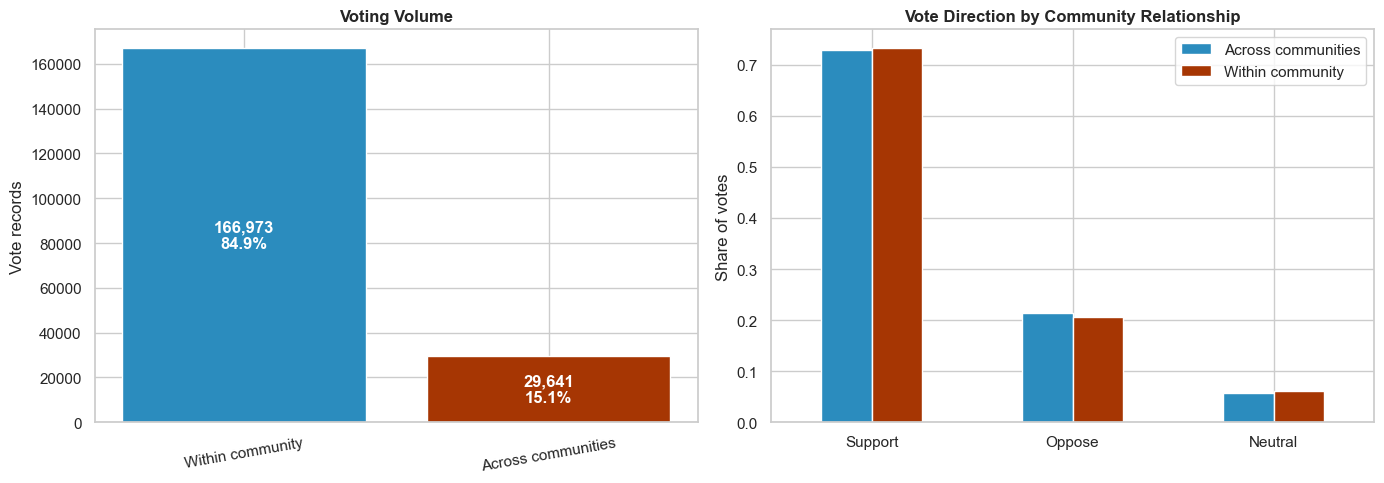

Support gap, within minus across: +0.3%
Oppose gap, within minus across: -0.9%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

volume = alignment.groupby("relationship")["count"].sum().reindex(["Within community", "Across communities"])
axes[0].bar(volume.index, volume.values, color=["#2b8cbe", "#a63603"])
axes[0].set_title("Voting Volume")
axes[0].set_ylabel("Vote records")
axes[0].tick_params(axis="x", rotation=10)
for i, v in enumerate(volume.values):
    axes[0].text(i, v * 0.5, f"{v:,}\n{v / volume.sum():.1%}", ha="center", va="center", color="white", fontweight="bold")

share_pivot = alignment.pivot(index="vote", columns="relationship", values="share").reindex(["Support", "Oppose", "Neutral"])
share_pivot.plot(kind="bar", ax=axes[1], color=["#2b8cbe", "#a63603"])
axes[1].set_title("Vote Direction by Community Relationship")
axes[1].set_ylabel("Share of votes")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="")

plt.tight_layout()
plt.show()

support_gap = share_pivot.loc["Support", "Within community"] - share_pivot.loc["Support", "Across communities"]
oppose_gap = share_pivot.loc["Oppose", "Within community"] - share_pivot.loc["Oppose", "Across communities"]
print(f"Support gap, within minus across: {support_gap:+.1%}")
print(f"Oppose gap, within minus across: {oppose_gap:+.1%}")


### Voting alignment interpretation

Most voting activity happens within communities, so the communities are structurally meaningful. However, the vote direction shares are not dramatically different across the two relationship types. This is an important nuance for the story: the network is clustered, but clustered does not automatically mean ideologically polarized. The website should make this distinction clear because it is one of the more interesting findings.


### Text processing and sentiment

The dataset also includes free text. We use two simple, interpretable text tools:

- **Regular expressions** to tokenize text and remove markup-like fragments. Wikipedia comments contain apostrophes, links, user signatures, and HTML-like snippets, so regex cleaning is necessary before counting words.
- **TF-IDF** to find terms that are relatively distinctive for support, opposition, and neutral votes. TF-IDF is useful here because common words are less informative than words that separate one vote type from another.

For sentiment, we use VADER when available. VADER is designed for short social-media-like text, so it is a reasonable first-pass tool for short vote explanations. Sentiment is not treated as ground truth; it is a descriptive signal that should be interpreted alongside the actual words.


/var/folders/24/7l8ktknd6h5dmc86_rd7_2sr0000gn/T/ipykernel_50908/2778259604.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


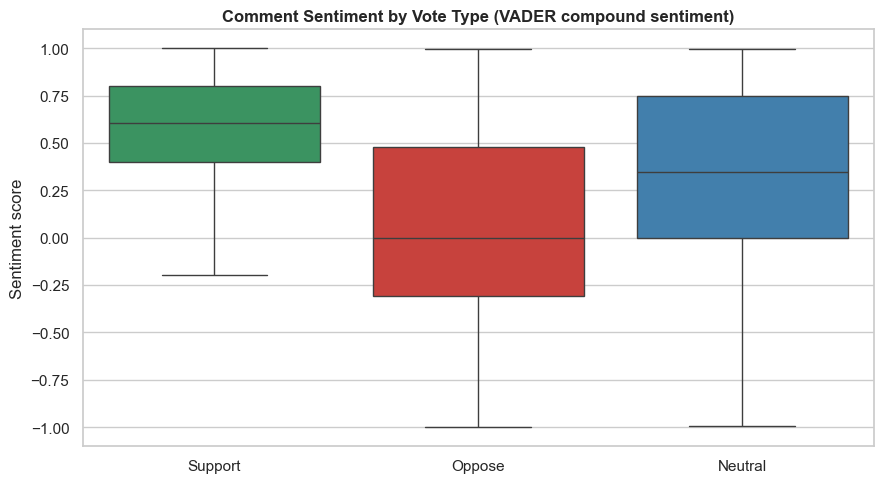

,count,mean,median
vote_label,,,
Support,143879,0.521762,0.6070
Oppose,40667,0.072680,0.0000
Neutral,12068,0.279765,0.3451


In [12]:
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    analyzer = SentimentIntensityAnalyzer()
    df["sentiment"] = df["TXT"].astype(str).apply(lambda text: analyzer.polarity_scores(text)["compound"])
    sentiment_method = "VADER compound sentiment"
except ImportError:
    positive_words = {"support", "good", "great", "strong", "excellent", "trust", "helpful", "agree", "qualified"}
    negative_words = {"oppose", "concern", "weak", "bad", "problem", "not", "lack", "poor", "unqualified"}
    def simple_sentiment(text):
        words = re.findall(r"\b[a-z]+\b", str(text).lower())
        if not words:
            return 0.0
        return (sum(w in positive_words for w in words) - sum(w in negative_words for w in words)) / np.sqrt(len(words))
    df["sentiment"] = df["TXT"].apply(simple_sentiment)
    sentiment_method = "simple lexicon fallback"

sentiment_by_vote = df.assign(vote_label=df["VOT"].map(vote_labels))

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=sentiment_by_vote,
    x="vote_label",
    y="sentiment",
    order=["Support", "Oppose", "Neutral"],
    palette=["#2ca25f", "#de2d26", "#3182bd"],
    showfliers=False,
    ax=ax,
)
ax.set_title(f"Comment Sentiment by Vote Type ({sentiment_method})")
ax.set_xlabel("")
ax.set_ylabel("Sentiment score")
plt.tight_layout()
plt.show()

sentiment_by_vote.groupby("vote_label")["sentiment"].agg(["count", "mean", "median"]).reindex(["Support", "Oppose", "Neutral"])


In [13]:
def clean_text_for_terms(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"'{2,}|\[\[|\]\]|<[^>]+>", " ", text)
    tokens = re.findall(r"\b[a-z][a-z]+\b", text)
    custom_stopwords = {
        "support", "oppose", "neutral", "abstain", "font", "color", "span", "style",
        "wikipedia", "wiki", "user", "admin", "rfa", "http", "https", "org", "php", "title"
    }
    stopwords = set(ENGLISH_STOP_WORDS) | custom_stopwords
    return " ".join(t for t in tokens if t not in stopwords and len(t) > 2)

text_docs = []
for vote in [1, -1, 0]:
    joined = " ".join(df.loc[df["VOT"] == vote, "TXT"].astype(str))
    text_docs.append(clean_text_for_terms(joined))

tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2))
X = tfidf.fit_transform(text_docs)
terms = np.array(tfidf.get_feature_names_out())

rows = []
for i, vote in enumerate([1, -1, 0]):
    scores = X[i].toarray().ravel()
    top_idx = scores.argsort()[-12:][::-1]
    for rank, idx in enumerate(top_idx, 1):
        rows.append({"vote": vote_labels[vote], "term": terms[idx], "score": scores[idx], "rank": rank})

top_terms = pd.DataFrame(rows)
top_terms


,vote,term,score,rank
0,Support,good,0.558540,1
1,Support,editor,0.241598,2
2,Support,tools,0.229231,3
3,Support,candidate,0.201334,4
4,Support,great,0.173540,5
5,Support,work,0.168306,6
6,Support,strong,0.162627,7
7,Support,like,0.151356,8
8,Support,think,0.141743,9
9,Support,make,0.132096,10


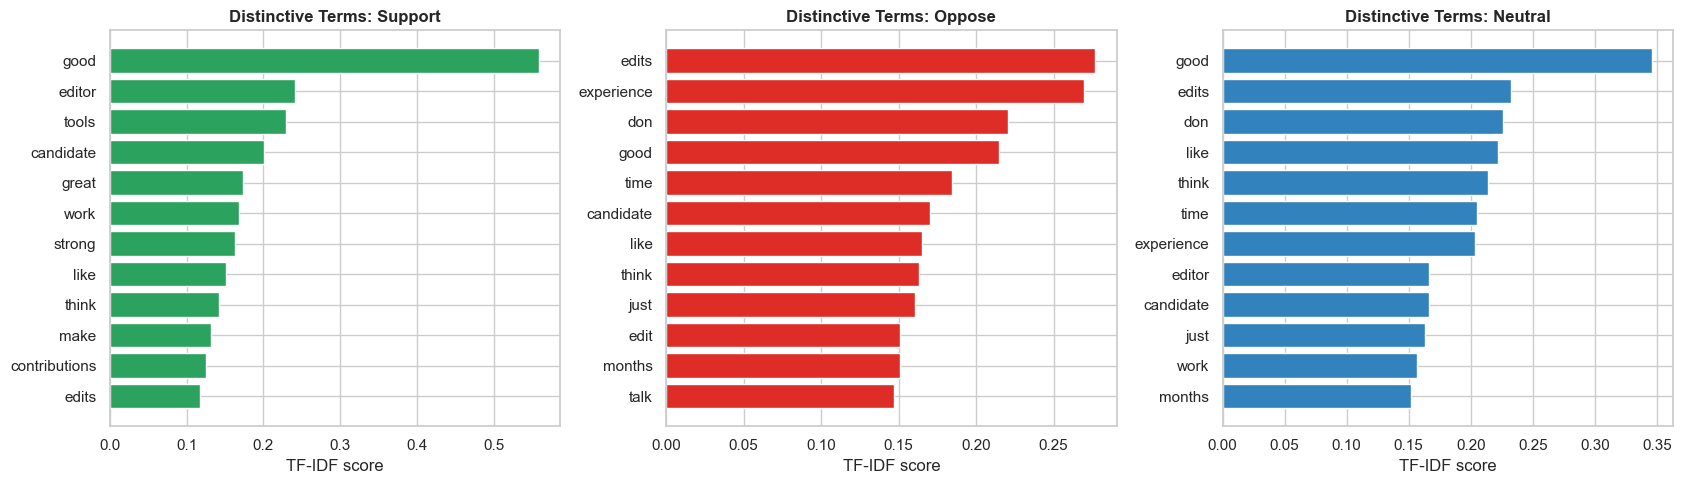

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=False)
colors = {"Support": "#2ca25f", "Oppose": "#de2d26", "Neutral": "#3182bd"}

for ax, vote_name in zip(axes, ["Support", "Oppose", "Neutral"]):
    subset = top_terms[top_terms["vote"] == vote_name].sort_values("score", ascending=True)
    ax.barh(subset["term"], subset["score"], color=colors[vote_name])
    ax.set_title(f"Distinctive Terms: {vote_name}")
    ax.set_xlabel("TF-IDF score")

plt.tight_layout()
plt.show()


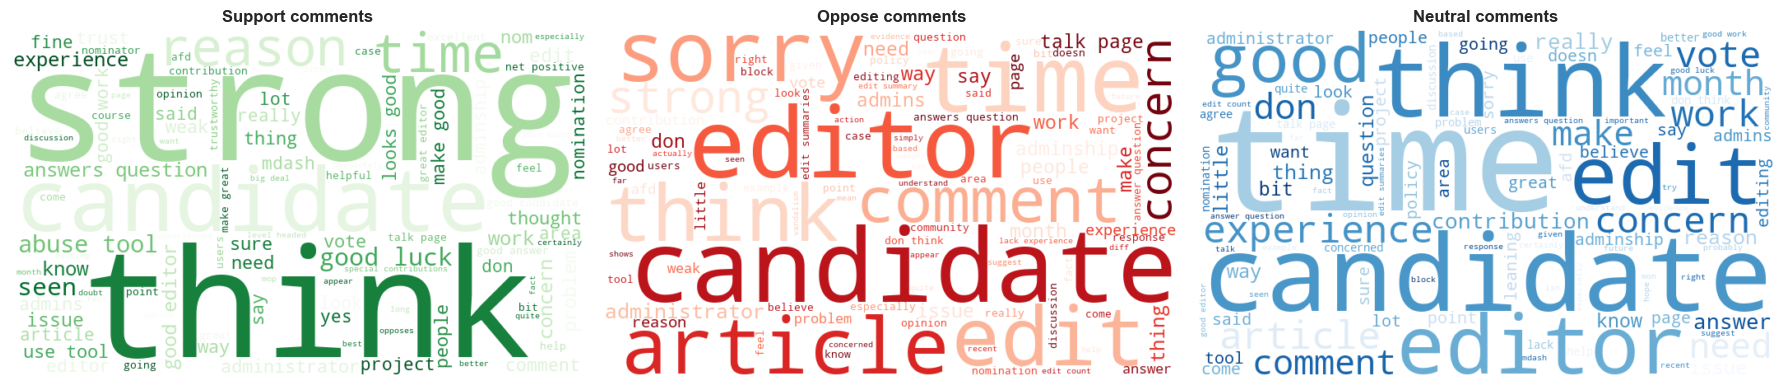

In [15]:
# Optional word clouds. The TF-IDF chart above is the primary reproducible text visualization.
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cmaps = {"Support": "Greens", "Oppose": "Reds", "Neutral": "Blues"}
    for ax, vote, label in zip(axes, [1, -1, 0], ["Support", "Oppose", "Neutral"]):
        wc = WordCloud(width=700, height=420, background_color="white", colormap=cmaps[label], max_words=100).generate(text_docs[[1, -1, 0].index(vote)])
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"{label} comments")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("wordcloud is not installed; skipping optional word cloud visualization.")


### Text analysis interpretation

Support comments tend to contain endorsement language about competence, trust, and suitability. Opposition comments more often mention experience, edits, concerns, and reasons for withholding trust. Neutral comments are more mixed and deliberative. The TF-IDF plot is more reliable than the word cloud for comparison because it downweights very common words and highlights terms that distinguish vote categories.

This supports the website story: RfA is not only a voting network. It is also a public justification system where editors explain what they consider good evidence for trust.


## 4. Discussion

### What went well?

The dataset works well for the project because it naturally combines network analysis and text analysis. The directed graph representation is intuitive: voters point toward candidates. Community detection reveals that the network is not homogeneous, and broker analysis gives us concrete users who connect parts of the network. The text analysis gives the network a human layer by showing how people justify support, opposition, and neutrality.

The most important conceptual result is the distinction between **structural clustering** and **behavioral polarization**. The RfA network contains communities, but vote direction is not radically different inside versus across communities. That is a more careful story than simply saying that clusters equal conflict.

### What is still missing?

Several improvements would make the analysis stronger:

- The timestamp column should be parsed more carefully so the website can show how voting behavior changes over time.
- Community detection should be compared across multiple algorithms, such as Louvain/Leiden if available, not only greedy modularity.
- Sentiment analysis should be validated with manual examples because VADER can misread Wikipedia-specific sarcasm, templates, and procedural language.
- Text analysis could be extended with topic modeling or embeddings to identify richer themes than individual words.
- The website should expose downloadable cleaned data files and a simplified network edge list so readers can explore the dataset themselves.

### Critical reflection

The analysis is descriptive rather than causal. We can show that editors form communities and that vote language differs by vote type, but we cannot claim that community membership causes a vote. The best website framing is therefore exploratory: it should show how trust is expressed and organized in Wikipedia adminship discussions, while being clear about the limits of the methods.
